<a href="https://colab.research.google.com/github/bimaadiwijaya8/-ML_05_Bima-Adiwijaya/blob/main/JS05/JS05-Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('voice.csv')

In [3]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

X = df.drop('label', axis=1)
y = df['label']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
selector = SelectKBest(score_func=f_classif, k=10) # Memilih 10 fitur teratas
X_train_opt = selector.fit_transform(X_train_scaled, y_train)
X_test_opt = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()].tolist()
print("Fitur Terpilih (10 Terbaik):", selected_features)

Fitur Terpilih (10 Terbaik): ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun', 'mindom']


In [7]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 10-Fold Cross-Validation pada data training
    scores = cross_val_score(knn, X_train_opt, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
best_score = max(cv_scores)
print(f"Nilai K Terbaik: {best_k} dengan Akurasi Cross-Validation: {best_score:.4f}")

Nilai K Terbaik: 4 dengan Akurasi Cross-Validation: 0.9775


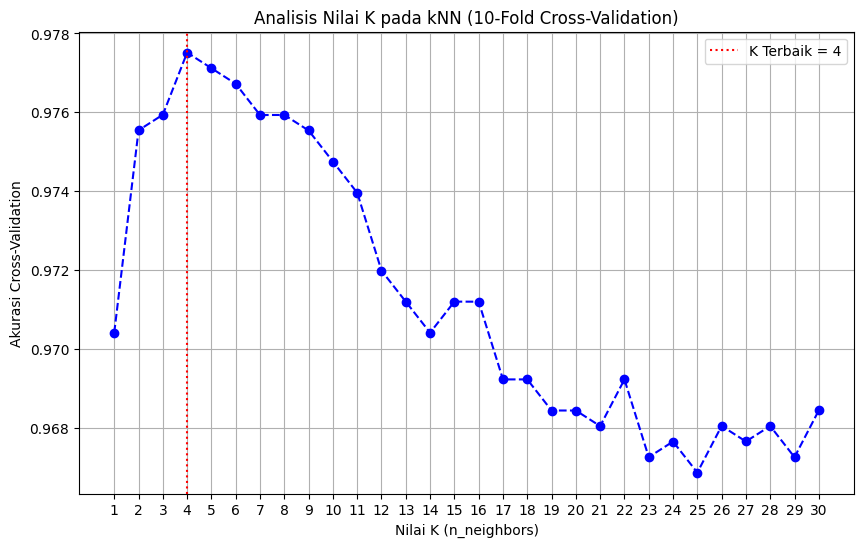

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o', linestyle='--', color='b')
plt.title('Analisis Nilai K pada kNN (10-Fold Cross-Validation)')
plt.xlabel('Nilai K (n_neighbors)')
plt.ylabel('Akurasi Cross-Validation')
plt.xticks(k_range)
plt.grid(True)
plt.axvline(x=best_k, color='r', linestyle=':', label=f'K Terbaik = {best_k}')
plt.legend()
plt.show()

In [9]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_opt, y_train)
y_pred = final_model.predict(X_test_opt)

print("\n--- Hasil Evaluasi pada Data Test ---")
print(f"Akurasi Test: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


--- Hasil Evaluasi pada Data Test ---
Akurasi Test: 0.9842

Classification Report:
               precision    recall  f1-score   support

      female       0.98      0.98      0.98       317
        male       0.98      0.98      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634

